In [1]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from ploting_func import *

In [2]:
def load_analysis_results(data_folder):
    """
    Load analysis results from saved netCDF file
    
    Parameters:
    -----------
    data_folder : str
        Folder containing the saved results
        
    Returns:
    --------
    results_df : pd.DataFrame
        DataFrame with analysis results
    """
    h5_path = os.path.join(data_folder, 'ramsey_analysis_results.h5')
    if not os.path.exists(h5_path):
        raise FileNotFoundError(f"Results file not found: {h5_path}")
    
    # Load xarray dataset and convert back to DataFrame
    ds = xr.load_dataset(h5_path)
    results_df = ds.to_dataframe().reset_index()
    
    print(f"Loaded results with {len(results_df)} entries")
    print(f"Successful fits: {results_df['abscos_fit_success'].sum()}")
    
    return results_df

In [3]:
# Example usage - Load data and create plots
# Set the data folder path
data_folder = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20251201\r_9_150x50_50_s300_ro_005x18_s100_fb\set_5"

# Load the saved analysis results
try:
    results_df = load_analysis_results(data_folder)
    
    # Print summary
    print(f"\n{'='*60}")
    print("PLOTTING RESULTS")
    print(f"{'='*60}")
    
    # Show successful results
    successful_results = results_df[results_df['abscos_fit_success'] == True]
    if len(successful_results) > 0:
        print(f"Phase values (mean ± std): {successful_results['abscos_phase'].mean():.4f} ± {successful_results['abscos_phase'].std():.4f}")
        print(f"Phase range: {successful_results['abscos_phase'].min():.4f} to {successful_results['abscos_phase'].max():.4f}")
    
    print("\\nData loaded successfully. You can now run the plotting functions:")
    print("- plot_phase_values(results_df, data_folder)  # Saves to folder")
    print("- plot_phase_values(results_df)  # Display only, no saving")
    print("- plot_2d_frequency_map(results_df, data_folder)")
    
except Exception as e:
    print(f"Error loading data: {e}")
    print("Make sure to run the analysis script first to generate the .h5 file")

Loaded results with 975 entries
Successful fits: 975

PLOTTING RESULTS
Phase values (mean ± std): 0.1178 ± 0.2383
Phase range: -0.3842 to 0.5541
\nData loaded successfully. You can now run the plotting functions:
- plot_phase_values(results_df, data_folder)  # Saves to folder
- plot_phase_values(results_df)  # Display only, no saving
- plot_2d_frequency_map(results_df, data_folder)


Creating individual plots...
Phase × Frequency product plot saved to: D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20251201\r_9_150x50_50_s300_ro_005x18_s100_fb\set_5\ramsey_phase_freq_product_vs_relative_time.png


d:\github\QCAT\temp\MIST\ploting_func.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=14)


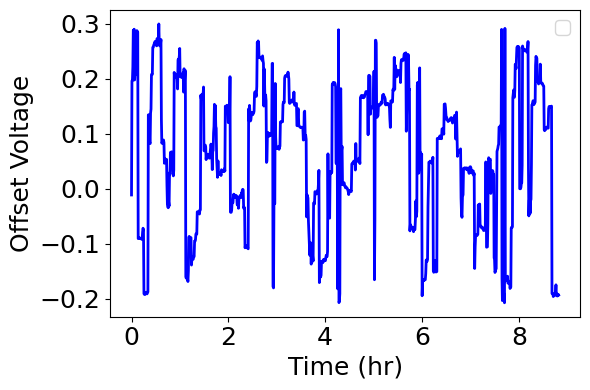

Phase × Frequency differences plot saved to: D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20251201\r_9_150x50_50_s300_ro_005x18_s100_fb\set_5\ramsey_phase_freq_diff_vs_relative_time.png


d:\github\QCAT\temp\MIST\ploting_func.py:271: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=14)
d:\github\QCAT\temp\MIST\ploting_func.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


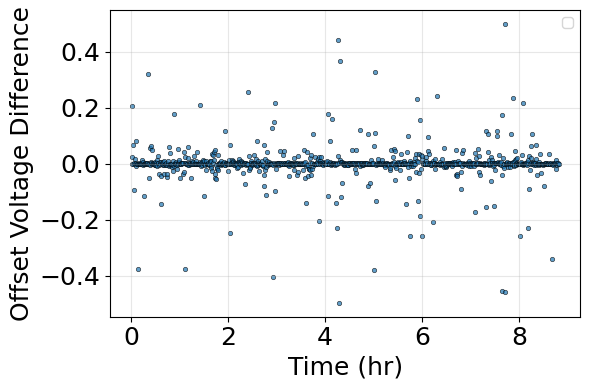

\nTo use time-based x-axis, change x_axis='run_start' in the function calls above


In [4]:
# Create individual plots with option to use time axis
if 'results_df' in locals():
    print("Creating individual plots...")
    
    # Plot phase values vs index
    fig1 = plot_phase_values(results_df, data_folder, x_axis='run_start')
    if fig1 is not None:
        plt.show()
    
    # # Plot frequency values vs index  
    # fig2 = plot_frequency_values(results_df, data_folder, x_axis='index')
    # if fig2 is not None:
    #     plt.show()
    
    # Plot phase differences vs index
    fig3 = plot_phase_differences(results_df, data_folder, x_axis='run_start')
    if fig3 is not None:
        plt.show()
        
    print("\\nTo use time-based x-axis, change x_axis='run_start' in the function calls above")
else:
    print("Please run the data loading cell first!")

Phase × Frequency histogram saved to: D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20251201\r_9_150x50_50_s300_ro_005x18_s100_fb\set_5\ramsey_phase_freq_product_histogram.png


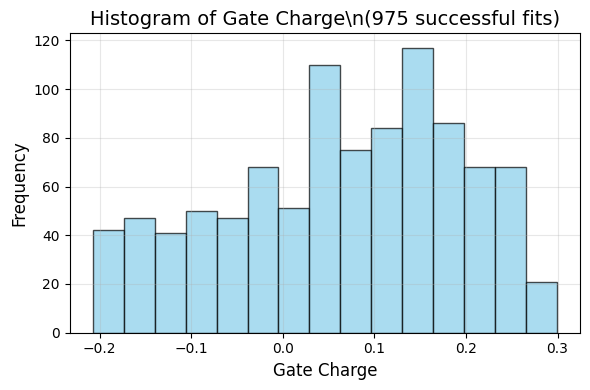

In [5]:
# Create Phase Histogram
if 'results_df' in locals():
    fig3 = plot_phase_histogram(results_df, data_folder, bins=15)
    if fig3 is not None:
        plt.show()
else:
    print("Please run the data loading cell first!")

## I/Q Colormap Plotting Functions
Functions for plotting readout power I/Q data as 2D colormaps.

In [16]:
def plot_iq_colormaps(dataset, save_path=None, prepared_state=None):
    """
    Plot I and Q data as 2D colormaps with charge_gate vs amp_prefactor.
    Average over shot_idx dimension. Handle prepared_state dimension if present.
    
    Parameters:
    -----------
    dataset : xr.Dataset
        Dataset containing I and Q data variables
    save_path : str, optional
        Path to save the plot. If None, plot will be displayed
    prepared_state : int, optional
        Which prepared state to plot (0 or 1). If None, plots both states separately
        
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure
    """
    
    # Check if prepared_state dimension exists
    has_prepared_state = 'prepared_state' in dataset.dims
    
    if has_prepared_state:
        prepared_states = dataset.coords['prepared_state'].values
        print(f"Dataset has prepared_state dimension with values: {prepared_states}")
        
        if prepared_state is not None:
            # Plot specific prepared state
            plot_dataset = dataset.sel(prepared_state=prepared_state)
            state_suffix = f"_state{prepared_state}"
            state_title = f" (State {prepared_state})"
        else:
            # Plot all prepared states separately
            figures = []
            for state in prepared_states:
                print(f"Plotting prepared state: {state}")
                state_save_path = None
                if save_path:
                    # Insert state suffix before file extension
                    base, ext = os.path.splitext(save_path)
                    state_save_path = f"{base}_state{state}{ext}"
                
                fig = plot_iq_colormaps(dataset, save_path=state_save_path, prepared_state=state)
                figures.append(fig)
            return figures
    else:
        # No prepared_state dimension
        plot_dataset = dataset
        state_suffix = ""
        state_title = ""
    
    # Get I and Q data and average over shot_idx and experiment dimensions
    i_mean = plot_dataset['I'].mean(dim=['shot_idx', 'experiment'])
    q_mean = plot_dataset['Q'].mean(dim=['shot_idx', 'experiment'])
    
    # Squeeze out any singleton dimensions to ensure 2D data for plotting
    i_mean = i_mean.squeeze()
    q_mean = q_mean.squeeze()
    
    # Get coordinates - handle different coordinate names
    if 'charge_gate' in plot_dataset.coords:
        charge_gates = plot_dataset.coords['charge_gate'].values
        x_label = 'Charge Gate (V)'
    elif 'normalized_charge_gate' in plot_dataset.coords:
        charge_gates = plot_dataset.coords['normalized_charge_gate'].values
        x_label = 'Normalized Charge Gate (V)'
    else:
        raise ValueError("No charge gate coordinate found in dataset")
    
    amp_prefactors = plot_dataset.coords['amp_prefactor'].values
    
    # Create meshgrid
    X, Y = np.meshgrid(charge_gates, amp_prefactors)
    
    # Transpose data for pcolormesh (amp_prefactor, charge_gate)
    i_plot_data = i_mean.T.values
    q_plot_data = q_mean.T.values
    
    print(f"Plotting data shapes - I: {i_plot_data.shape}, Q: {q_plot_data.shape}")
    print(f"Meshgrid shapes - X: {X.shape}, Y: {Y.shape}")
    
    # Create figure
    fig, (ax_i, ax_q) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot I data
    im_i = ax_i.pcolormesh(X, Y, i_plot_data, shading='auto', cmap='viridis')
    ax_i.set_title(f'I Signal{state_title}')
    ax_i.set_xlabel(x_label)
    ax_i.set_ylabel('Amplifier Prefactor')
    plt.colorbar(im_i, ax=ax_i, label='I Signal')
    
    # Plot Q data
    im_q = ax_q.pcolormesh(X, Y, q_plot_data, shading='auto', cmap='plasma')
    ax_q.set_title(f'Q Signal{state_title}')
    ax_q.set_xlabel(x_label)
    ax_q.set_ylabel('Amplifier Prefactor')
    plt.colorbar(im_q, ax=ax_q, label='Q Signal')
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Plot saved to: {save_path}")
    
    return fig

Loading readout dataset...
Readout dataset loaded successfully!
Dataset dimensions: {'experiment': 269, 'qubit': 1, 'prepared_state': 2, 'normalized_charge_gate': 93, 'amp_prefactor': 41, 'shot_idx': 50}
Data variables: ['I1', 'Q1', 'I', 'Q', 'n']
Coordinates: ['normalized_charge_gate', 'shot_idx', 'amp_prefactor', 'prepared_state', 'qubit', 'experiment']
\nCreating I/Q colormap plots...
Dataset has prepared_state dimension with values: [0 1]
Plotting prepared state: 0
Dataset has prepared_state dimension with values: [0 1]
Plotting data shapes - I: (41, 93), Q: (41, 93)
Meshgrid shapes - X: (41, 93), Y: (41, 93)
✅ Plot saved to: D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20251201\r_9_150x50_50_s300_ro_005x18_s100_fb\set_5\iq_colormaps_from_notebook_state0.png
Plotting prepared state: 1
Dataset has prepared_state dimension with values: [0 1]
Plotting data shapes - I: (41, 93), Q: (41, 93)
Meshgrid shapes - X: (41, 93), Y: (41, 93)
✅ Plot saved to: D:\SynologyDrive\LiChieh

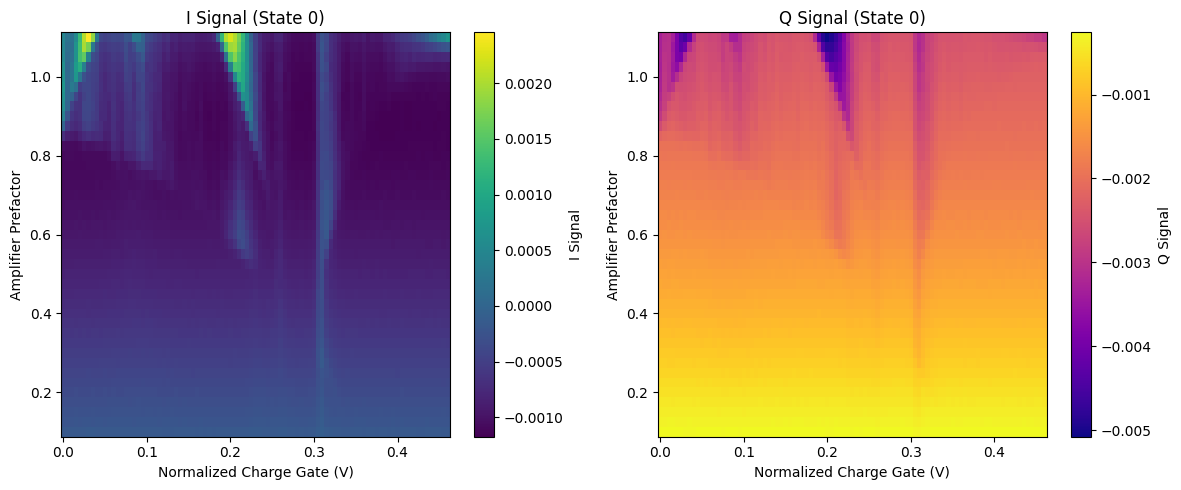

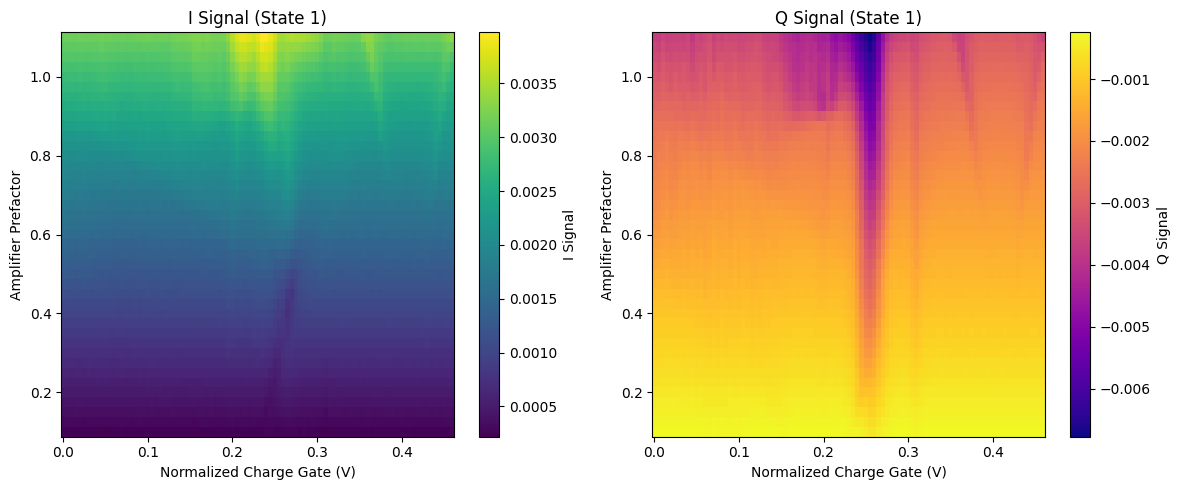

In [17]:
# Load and plot I/Q readout data
# This requires running shot_combiner.py first to generate the readout dataset

try:
    # Load the concatenated readout dataset
    readout_dataset_path = os.path.join(data_folder, 'final_readout_dataset.h5')
    
    if os.path.exists(readout_dataset_path):
        print("Loading readout dataset...")
        readout_dataset = xr.load_dataset(readout_dataset_path)
        
        print(f"Readout dataset loaded successfully!")
        print(f"Dataset dimensions: {dict(readout_dataset.sizes)}")
        print(f"Data variables: {list(readout_dataset.data_vars.keys())}")
        print(f"Coordinates: {list(readout_dataset.coords.keys())}")
        
        # Create I/Q colormap plots (automatically handles prepared_state dimension)
        print("\\nCreating I/Q colormap plots...")
        figs = plot_iq_colormaps(readout_dataset, 
                                save_path=os.path.join(data_folder, "iq_colormaps_from_notebook.png"))
        
        if isinstance(figs, list):
            print(f"Created {len(figs)} separate plots for different prepared states")
            for fig in figs:
                plt.show()
        else:
            plt.show()
            
    else:
        print(f"Readout dataset not found at: {readout_dataset_path}")
        print("Please run shot_combiner.py first to generate the readout dataset")
        
except Exception as e:
    print(f"Error loading or plotting readout data: {e}")
    print("Make sure shot_combiner.py has been run to generate the readout dataset")

## RO Fidelity Power Analysis
Run `ROFidelityPower` analysis per qubit and plot 2D colormaps of `p_outlier`, `norm_res`, and `std`.

State 0: Max p_outlier = 0.553903 at charge_gate = 0.1087, amp_prefactor = 1.1000
State 1: Max p_outlier = 0.694349 at charge_gate = 0.1386, amp_prefactor = 1.0750


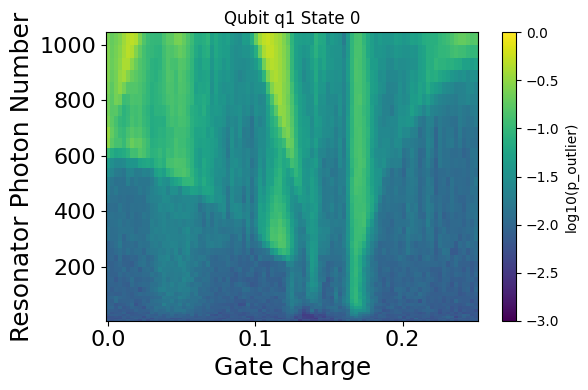

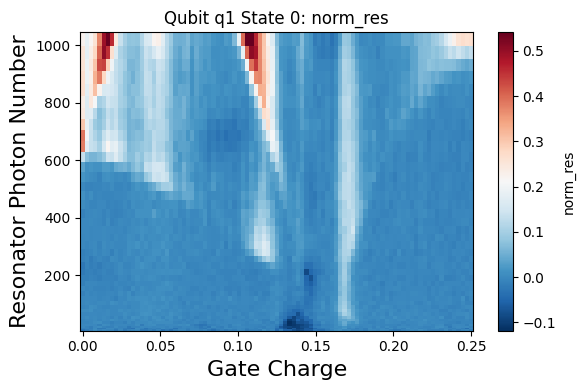

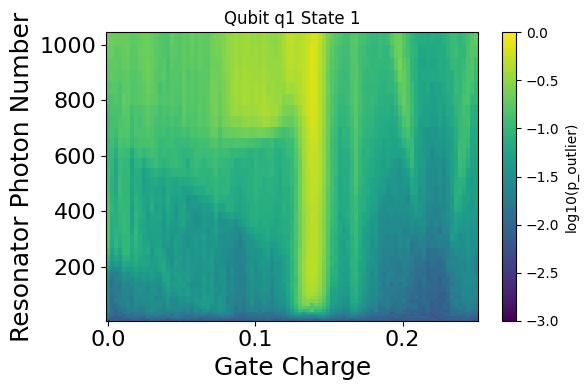

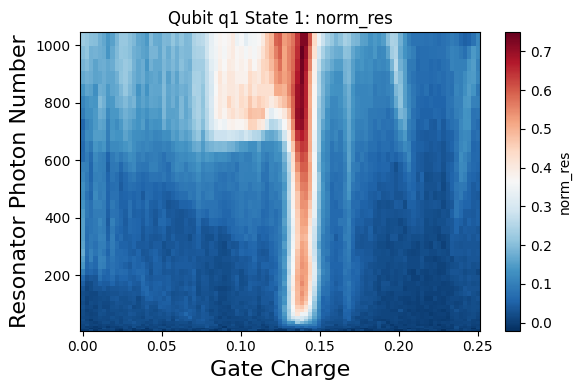

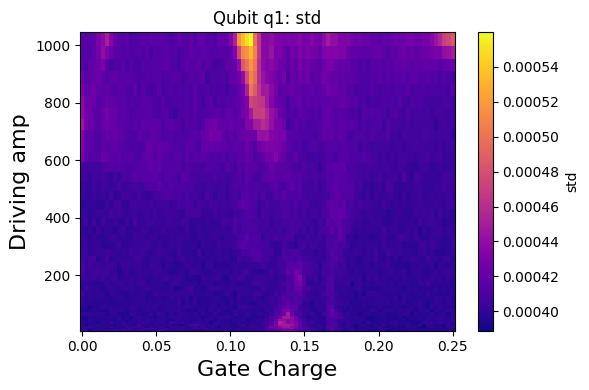

In [4]:
# === Configuration ===
base_dir = r'D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20251201\r_9_150x50_50_s300_ro_005x18_s100_fb\set_5\free'
dataset_path = os.path.join(base_dir, 'merged_summary_qubit_q1.h5')
norm_ac_shift = 166 / 4912.0 *25000  # shift / f_ro
charge_period = 0.460           # Volt

assign_std  = None   # e.g. 0.000396
assign_mean = None   # e.g. load_xarray_h5(r"...\fit_mean.nc")


summary = xr.load_dataset(dataset_path)
# Plot 2D colormaps for each qubit
figs = plot_ro_fidelity_2d(
    summary, "q1", base_dir,
    norm_ac_shift=norm_ac_shift,
    charge_period=charge_period,
)

# for f in figs:
#     plt.show()
